   Project_ID Project_Name Department  Project_Manager  Budget  Amount_Spent  \
0           1    Project_1         HR     Alison Moore  461883        430046   
1           2    Project_2         HR    Kaitlyn Smith  466790        230748   
2           3    Project_3         IT    Douglas Jones  399281        147938   
3           4    Project_4         HR    Jill Williams  162493        157928   
4           5    Project_5         HR  Michael Herrera  238125        139911   

   Team_Size  Duration_Months  Risk_Score Priority Project_Status  
0         11                1          10      Low      Completed  
1         19                8           1      Low    In Progress  
2         15                6           3     High    In Progress  
3          4                1           7   Medium      Completed  
4         17                8           9   Medium    In Progress  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   C

/tmp/ipykernel_3364/1444658088.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_3364/1444658088.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

Accuracy Score : 0.3


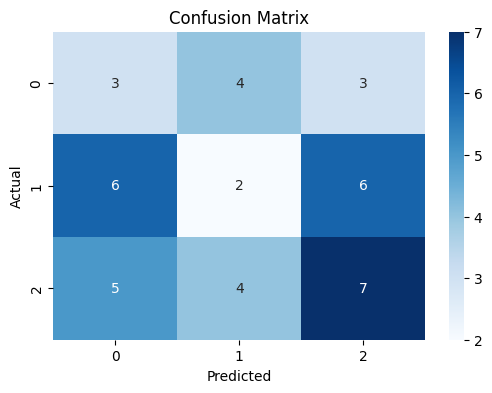

              precision    recall  f1-score   support

           0       0.21      0.30      0.25        10
           1       0.20      0.14      0.17        14
           2       0.44      0.44      0.44        16

    accuracy                           0.30        40
   macro avg       0.28      0.29      0.28        40
weighted avg       0.30      0.30      0.30        40



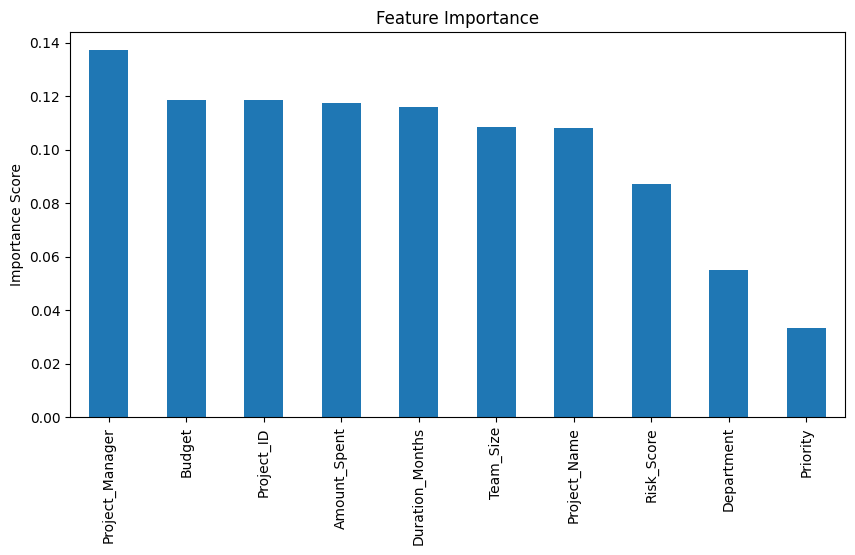

Model Training and Evaluation Completed


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

df = pd.read_csv("/content/Project_Management_Sample_Data.csv")

print(df.head())

print(df.info())

print(df.isnull().sum())

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

label_encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = label_encoder.fit_transform(df[col])

print(df.head())

target_column = df.columns[-1]

X = df.drop(target_column, axis=1)

y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

print(classification_report(y_test, y_pred))

if len(np.unique(y)) == 2:

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,4))

    plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Feature Importance")

plt.ylabel("Importance Score")

plt.show()

print("Model Training and Evaluation Completed")